In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torch
from tqdm import tqdm
from pathlib import Path
import shutil

## --MASKING TEST AND MASKING SCRIPT--


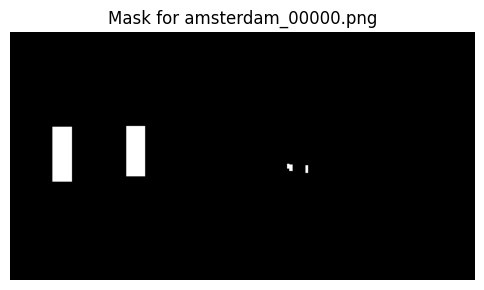

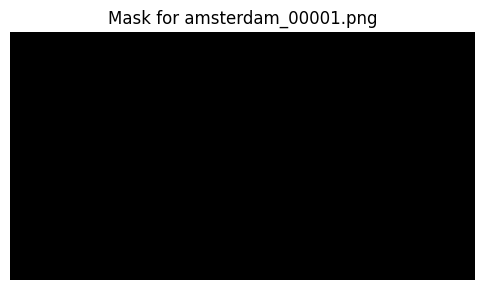

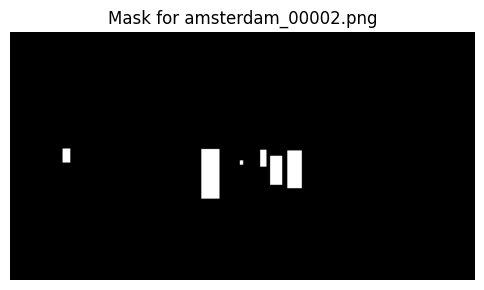

In [3]:
# Define the dataset path
image_folder = "../../data/eurocity/ECP_day_img_train/ECP/day/img/train/amsterdam/"  # Change this to your image directory
annotation_folder = "../../data/eurocity/ECP_day_labels_train/ECP/day/labels/train/amsterdam/"  # Change to your JSON annotations folder

# Define the class of interest
TARGET_CLASSES = ["pedestrian","person-group-far-away","rider","rider+vehicle-group-far-away"]  # Adjust if needed

def load_json_annotation(json_path):
    """ Load and parse JSON annotation file. """
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def create_person_mask(image_size, annotations):
    """ Generate a binary mask from bounding boxes of the specified classes. """
    width, height = image_size
    mask = Image.new("L", (width, height), 0)  # Create blank mask (grayscale)
    draw = ImageDraw.Draw(mask)

    for obj in annotations["children"]:  # Extract objects from "children"
        if obj["identity"] in TARGET_CLASSES:  # Check if class matches
            x_min, y_min, x_max, y_max = obj["x0"], obj["y0"], obj["x1"], obj["y1"]
            draw.rectangle([x_min, y_min, x_max, y_max], fill=1)  # Draw bounding box

    return torch.tensor(np.array(mask), dtype=torch.float32)  # Convert to PyTorch tensor

# 🔹 Process all images
count = 0
for image_name in sorted(os.listdir(image_folder)):
    if not image_name.endswith(".png"):  # Process only PNG files
        continue

    # Get corresponding annotation file (assuming same name but .json)
    json_path = os.path.join(annotation_folder, image_name.replace(".png", ".json"))
    if not os.path.exists(json_path):
        print(f"Warning: No annotation found for {image_name}")
        continue

    # Load image to get size
    image_path = os.path.join(image_folder, image_name)
    image = Image.open(image_path)
    image_size = image.size  # (width, height)

    # Load annotation
    annotations = load_json_annotation(json_path)

    # Generate binary mask
    mask = create_person_mask(image_size, annotations)

    # Show the mask
    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.title(f"Mask for {image_name}")
    plt.show()
    count+=1
    if count>2 :break  # Remove this to process all images


## Here script for mask generation

In [11]:
# 🔹 Define dataset structure
DATASET_ROOT = "../../data/eurocity/"
OUTPUT_FOLDER = "../../data/eurocity_masks/"  # Folder to store all masks together

# Directories to crawl
IMAGE_FOLDERS = [
    "ECP_day_img_train/ECP/day/img/train",
    "ECP_night_img_train/ECP/night/img/train",
    "ECP_day_img_val/ECP/day/img/val",
    "ECP_night_img_val/ECP/night/img/val",
]

LABEL_FOLDERS = [
    "ECP_day_labels_train/ECP/day/labels/train",
    "ECP_night_labels_train/ECP/night/labels/train",
    "ECP_day_labels_val/ECP/day/labels/val",
    "ECP_night_labels_val/ECP/night/labels/val",
]

# 🔹 Define the class of interest
TARGET_CLASSES = {"pedestrian", "person-group-far-away", "rider", "rider+vehicle-group-far-away"}

# Create output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def load_json_annotation(json_path):
    """Load and parse JSON annotation file."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def create_person_mask(image_size, annotations):
    """Generate a binary mask from bounding boxes of the specified classes."""
    width, height = image_size
    mask = Image.new("L", (width, height), 0)  # Blank mask (grayscale)
    draw = ImageDraw.Draw(mask)

    for obj in annotations["children"]:  # Extract objects from "children"
        if obj["identity"] in TARGET_CLASSES:  # Check if identity matches
            x_min, y_min, x_max, y_max = obj["x0"], obj["y0"], obj["x1"], obj["y1"]
            draw.rectangle([x_min, y_min, x_max, y_max], fill=1)  # Draw bounding box

    return torch.tensor(np.array(mask), dtype=torch.uint8)  # Convert to PyTorch tensor

# 🔹 Process images from all folders
for img_folder, lbl_folder in zip(IMAGE_FOLDERS, LABEL_FOLDERS):
    img_folder_path = os.path.join(DATASET_ROOT, img_folder)
    lbl_folder_path = os.path.join(DATASET_ROOT, lbl_folder)

    if not os.path.exists(img_folder_path) or not os.path.exists(lbl_folder_path):
        print(f"⚠️ Skipping missing folder: {img_folder_path} or {lbl_folder_path}")
        continue

    # Process all images
    for city in sorted(os.listdir(img_folder_path)):  # Crawl inside city subfolders
        city_img_path = os.path.join(img_folder_path, city)
        city_lbl_path = os.path.join(lbl_folder_path, city)

        if not os.path.isdir(city_img_path) or not os.path.isdir(city_lbl_path):
            continue  # Skip if not a valid city folder

        image_files = sorted(os.listdir(city_img_path))
        for image_name in tqdm(image_files, desc=f"Processing {city}"):
            if not image_name.endswith(".png"):
                continue

            json_path = os.path.join(city_lbl_path, image_name.replace(".png", ".json"))
            if not os.path.exists(json_path):
                print(f"⚠️ No annotation found for {image_name}")
                continue

            # Load image to get size
            image_path = os.path.join(city_img_path, image_name)
            image = Image.open(image_path)
            image_size = image.size  # (width, height)

            # Load annotation
            annotations = load_json_annotation(json_path)

            # Generate binary mask
            mask = create_person_mask(image_size, annotations)

            # Save mask
            mask_filename = os.path.join(OUTPUT_FOLDER, f"{image_name}")
            Image.fromarray(mask.numpy() * 255).save(mask_filename)  # Convert to 0-255 range

print("✅ All masks saved in:", OUTPUT_FOLDER)

Processing zagreb: 100%|██████████| 107/107 [00:01<00:00, 101.91it/s]

✅ All masks saved in: ../../data/eurocity_masks/


## --DATASET RESTRUCTURATION AND RESIZING--

In [9]:
# 🔹 Define paths
DATASET_ROOT = "../../data/eurocity"  # Change to your dataset root directory
OUTPUT_FOLDER = "../../data/eurocity_224"  # Where resized & unified data will be saved

# Expected dataset subsets
SUBSETS = ["test"]#["train", "val"]  # No "test"
CATEGORIES = ["ECP_day_img_", "ECP_night_img_"]  # Merge day & night

# 🔹 Create output directories
for subset in SUBSETS:
    os.makedirs(os.path.join(OUTPUT_FOLDER, subset), exist_ok=True)

# 🔹 Function to resize and save image
def process_and_save_image(src_path, dest_folder):
    """Resize image to 224x224 and save it."""
    try:
        img = Image.open(src_path).convert("RGB")  # Ensure 3-channel image
        img = img.resize((224, 224), Image.ANTIALIAS)
        img.save(os.path.join(dest_folder, os.path.basename(src_path)))  # Keep original filename
    except Exception as e:
        print(f"❌ Error processing {src_path}: {e}")

# 🔹 Process images for train and val
for subset in SUBSETS:  # Train, Val
    dest_folder = os.path.join(OUTPUT_FOLDER, subset)
    
    for category in CATEGORIES:  # Day & Night
        src_folder = os.path.join(DATASET_ROOT, f"{category}{subset}")
        
        if not os.path.exists(src_folder):
            print(f"⚠️ Skipping missing folder: {src_folder}")
            continue
        
        # Process each image
        image_files = list(Path(src_folder).rglob("*.png"))  # Adjust for other formats
        for img_path in tqdm(image_files, desc=f"Processing {subset} ({category})"):
            process_and_save_image(img_path, dest_folder)

print("✅ Dataset processing complete!")


Processing test (ECP_day_img_):   0%|          | 0/12059 [00:00<?, ?it/s]/tmp/ipykernel_7525/1881690869.py:18: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize((224, 224), Image.ANTIALIAS)
Processing test (ECP_night_img_): 100%|██████████| 2126/2126 [01:59<00:00, 17.81it/s]

✅ Dataset processing complete!
